In [1]:
using Pkg; Pkg.add(["ITensors", "ITensorMPS", "Plots", "LsqFit", "Statistics", "LinearAlgebra"])
using ITensors, ITensorMPS, Plots, LsqFit, Statistics, LinearAlgebra

include("../../data/params.jl")
include("../../data/helpers/saving.jl")
include("../schmidt_spectra/get_spectrum.jl")
include("../schmidt_spectra/deviation/deviation.jl")

   Resolving package versions...
  No Changes to `~/dev/uni/msciproject/Project.toml`
  No Changes to `~/dev/uni/msciproject/Manifest.toml`
   Resolving package versions...
  No Changes to `~/dev/uni/msciproject/Project.toml`
  No Changes to `~/dev/uni/msciproject/Manifest.toml`


find_deviation_idx (generic function with 1 method)

## Bounding Error

So we define our disordered state in terms of the clean and residual states
$$
\ket{\psi_{\sigma}} = \xi \ket{\psi_{0}} + \sqrt{ 1-\xi^{2} }\ket{\psi_{r}} 
$$
We can extract residual state use Gram-Schmidt orthogonalisation:
$$
\ket{\psi_{r}} = \ket{\psi_{\sigma}} - \xi \ket{\psi_{0}}   
$$
which is no longer normalised, but can be if required by $\frac{1}{\sqrt{ 1-\xi^{2} }}$.

For simplicity, we will say $\beta=\sqrt{1-\xi^2}$.

In [2]:
function get_residual_state(ψ_σ::MPS, ψ_0::MPS; normalize::Bool = true)
    ξ = inner(ψ_σ, ψ_0)
    ψ_r = ψ_σ - ξ * ψ_0
    return normalize ? normalize!(ψ_r) : ψ_r
end

get_residual_state (generic function with 1 method)

In [3]:
N = 60
σ = 0.001

system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 10,
                    "MAX_BOND_DIM" => 1000,
                    "ACC" => 10^-16
                    )


run_params_cln = Dict{String, Any}("N" => N, "σ" => 0.00)
run_params_dis = Dict{String, Any}("N" => N, "σ" => σ)

CURRENT_DIR = @__DIR__
FP = extract_filename_from_system_params(system_params)
MPS_FP = joinpath(CURRENT_DIR, "../../data/storage/perturb_sigma_$(σ)_$(FP).hd5")
matches_cln = find_runs_by_params(MPS_FP, run_params_cln; load_psi=true, instance_selection=:latest)
matches_dis = find_runs_by_params(MPS_FP, run_params_dis; load_psi=true, instance_selection=:latest)

ψ0 = matches_cln[1].psi
ψσ = matches_dis[1].psi

60-element MPS:
 ((dim=2|id=594|"S=1/2,Site,n=1") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=2|id=87|"Link,l=1") <Out>
 1: QN("Sz",-1) => 1
 2: QN("Sz",1) => 1)
 ((dim=4|id=92|"Link,l=2") <Out>
 1: QN("Sz",-2) => 1
 2: QN("Sz",0) => 2
 3: QN("Sz",2) => 1, (dim=2|id=141|"S=1/2,Site,n=2") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=2|id=87|"Link,l=1") <In>
 1: QN("Sz",-1) => 1
 2: QN("Sz",1) => 1)
 ((dim=2|id=898|"S=1/2,Site,n=3") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=8|id=893|"Link,l=3") <Out>
 1: QN("Sz",-3) => 1
 2: QN("Sz",-1) => 3
 3: QN("Sz",1) => 3
 4: QN("Sz",3) => 1, (dim=4|id=92|"Link,l=2") <In>
 1: QN("Sz",-2) => 1
 2: QN("Sz",0) => 2
 3: QN("Sz",2) => 1)
 ((dim=2|id=655|"S=1/2,Site,n=4") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=14|id=600|"Link,l=4") <Out>
 1: QN("Sz",-4) => 1
 2: QN("Sz",-2) => 4
 3: QN("Sz",0) => 4
 4: QN("Sz",2) => 4
 5: QN("Sz",4) => 1, (dim=8|id=893|"Link,l=3") <In>
 1: QN("Sz",-3) => 1
 2: QN("Sz",-1) => 3
 3

Quick plot of the Schmidt spectra of these states.

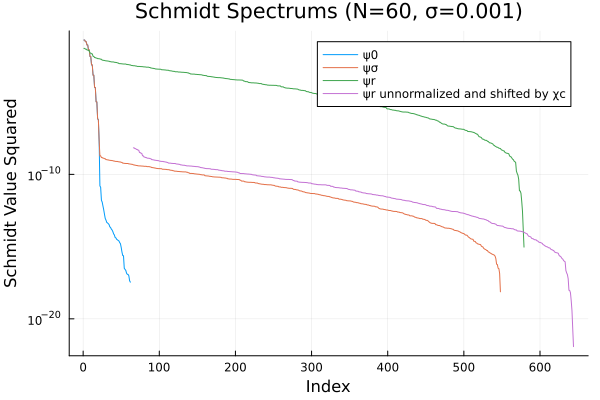

In [4]:
ψr = get_residual_state(ψσ, ψ0; normalize=true)
ψr_unnormalized = get_residual_state(ψσ, ψ0; normalize=false)

spec0 = get_squared_sorted_schmidt_spectrum_from_mps(ψ0)
specσ = get_squared_sorted_schmidt_spectrum_from_mps(ψσ)
specr = get_squared_sorted_schmidt_spectrum_from_mps(ψr)

specr_unnormalized = get_squared_sorted_schmidt_spectrum_from_mps(ψr_unnormalized)
χc = maxlinkdim(ψ0)
specr_padding = (1:length(specr_unnormalized)) .+ χc

p_cln_vs_dis_vs_r = plot(title="Schmidt Spectrums (N=$N, σ=$σ)", yscale=:log10, xlabel="Index", ylabel="Schmidt Value Squared")

plot!(p_cln_vs_dis_vs_r, 1:length(spec0), spec0, label="ψ0")
plot!(p_cln_vs_dis_vs_r, 1:length(specσ), specσ, label="ψσ")
plot!(p_cln_vs_dis_vs_r, 1:length(specr), specr, label="ψr")
plot!(p_cln_vs_dis_vs_r, specr_padding, specr_unnormalized, label="ψr unnormalized and shifted by χc")

display(p_cln_vs_dis_vs_r)

Let's check the overlap.

In [5]:
overlap_ψ0_ψσ = abs(inner(ψ0, ψσ))
overlap_ψ0_ψr = abs(inner(ψ0, ψr))
overlap_ψσ_ψr = abs(inner(ψr, ψσ))

println("<ψ0|ψσ> = ", overlap_ψ0_ψσ)
println("<ψ0|ψr> = ", overlap_ψ0_ψr)
println("<ψr|ψσ> = ", overlap_ψσ_ψr)

# should equal one if state is normalised
# this is ξ^2 + √(1-ξ^2) = 1
println("<ψ0|ψσ>^2 + <ψr|ψσ>^2 = ", overlap_ψ0_ψσ^2 + overlap_ψσ_ψr^2)

ξ = overlap_ψ0_ψσ
β = sqrt(1-ξ^2) # = overlap_ψr_ψσ

println("ξ = $ξ, β = $β")

<ψ0|ψσ> = 0.9999999349470586
<ψ0|ψr> = 1.9446163863207078e-11
<ψr|ψσ> = 0.0003607019301583468
<ψ0|ψσ>^2 + <ψr|ψσ>^2 = 1.000000000000004
ξ = 0.9999999349470586, β = 0.0003607019247456992


Clearly, we have a normalised state. We also have $\braket{\psi_0|\psi_r} = 0$ (or close enough), which means that all the disorder in the $\ket{\psi_\sigma}$ state is wrapped up inside $\ket{\psi_r}$.

In [6]:
# helper to fetch states for given N, σ
# returns Tuple(clean states, disordered states)
function fetch_states(
    N::Int, σ::Float64, system_params::Dict{String, Any};
    max::Union{Nothing, Int}=nothing, type::Symbol=:latest
)::Tuple{Vector{MPS}, Vector{MPS}}
    CURRENT_DIR = @__DIR__
    FP = extract_filename_from_system_params(system_params)
    MPS_FP = joinpath(CURRENT_DIR, "../../data/storage/perturb_sigma_$(σ)_$(FP).hd5")
    matches_cln = find_runs_by_params(MPS_FP, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=type)
    matches_dis = find_runs_by_params(MPS_FP, Dict{String, Any}("N"=>N, "σ"=>σ); load_psi=true, instance_selection=type)

    cln_mpss = MPS[]
    dis_mpss = MPS[]

    for (cln, dis) in zip(matches_cln, matches_dis)
        if (cln.psi === nothing || dis.psi === nothing)
            continue
        end

        push!(cln_mpss, cln.psi)
        push!(dis_mpss, dis.psi)

        if max !== nothing && length(cln_mpss) >= max
            break
        end
    end

    return cln_mpss, dis_mpss
end

fetch_states (generic function with 1 method)

### Infidelity scaling with disorder

It is useful to know how $\beta=\sqrt{1-\xi^2}$ scales with $\sigma$. 

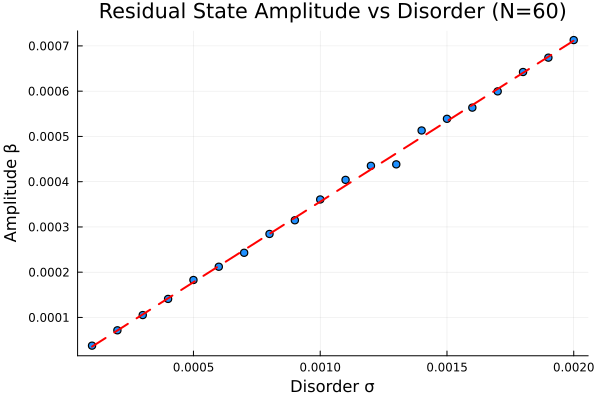

Disorder Weight Constant (C) = 0.356


In [11]:
N = 60
sigmas = 0.0001:0.0001:0.002
sysparams = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
)

get_β(ψ0, ψσ) = sqrt(1 - abs(inner(ψ0, ψσ))^2)

βs = Float64[]
valid_σs = Float64[]

for σ in sigmas
    ψ0s, ψσs = fetch_states(N, σ, sysparams)
    if !isempty(ψ0s) && !isempty(ψσs)
        push!(βs, get_β(ψ0s[1], ψσs[1]))
        push!(valid_σs, σ)
    end
end

p1 = scatter(valid_σs, βs,
             title="Residual State Amplitude vs Disorder (N=$N)",
             xlabel="Disorder σ", ylabel="Amplitude β",
             legend=false, grid=true, markerstrokewidth=1.5, color=:dodgerblue)


C_fit = valid_σs \ βs
plot!(p1, valid_σs, C_fit .* valid_σs, color=:red, lw=2, linestyle=:dash)
display(p1)

println("Disorder Weight Constant (C) = $(round(C_fit, digits=3))")

So we get that the amplitude of the residual state linearly increases with $\sigma$. Nice. This means that 
$$\beta = C \sigma$$

**TODO**: This of course is only for small values of $\sigma$. We will try and run this later for larger levels of disorder.

### Truncation Error

We can write a quick function to work out the truncation error of a state. This is given by the formula 
$$\varepsilon(\chi)^2 = \sum_{k=\chi+1}^D \lambda_k^2$$
where $D \equiv \chi_\text{max}$ is the maximum bond dimension, or the number of states in the spectrum.

In [8]:
function truncation_error(schmidt_spectrum::Vector{Float64}, χ::Int64)::Float64
    if χ >= length(schmidt_spectrum)
        # if χ greater than the length of the spectrum, not truncation occurs
        return 0.0
    end
    truncated = schmidt_spectrum[(χ + 1):end]
    return sqrt(sum(truncated)) # return sqrt of the sum of the truncated elements
end

truncation_error (generic function with 1 method)

Since $\ket{\psi_{0}}$ and $\ket{\psi_{r}}$ are globally orthogonal (by construction) and because the clean state has strictly zero weight in the 'tail' of the spectrum ($\alpha_{k}=0$ for $k>\chi_{c}$), the tail of the disordered state's Schmidt spectrum is entirely provided by the residual state.

Therefore, for any bond dimension $\chi\geq \chi_{c}$ the squared Schmidt values of the total state are the squared Schmidt values of the residual state, scaled by the residual states total probability weight
$$
d_{k}^{2} = (1-\xi^{2})r_{k}^{2} \quad \forall \: k> \chi_{c}
$$
Substituting this into the truncation error formula, we find 
$$
\varepsilon_{\text{total}}(\chi) = \sqrt{\sum_{k=\chi+1}^{D} (1-\xi^{2})r_{k}^{2}} = \sqrt{(1-\xi^{2}) \varepsilon_{r}(\chi)^2} = \beta \varepsilon_r(\chi) = C\sigma \varepsilon_r(\chi)
$$
where $\varepsilon_{r}(\chi)$ is simply the truncation error when chopping off states beyond a bond dimension of $\chi$ in the residual state.

If we want to talk about the error in this state, we need to know the distribution of Schmidt values in the tail. We can make then get an idea of what kind of error we can expect from the final result here. 

Assume that 
$$\varepsilon_r(\chi) \approx \exp(-\alpha(N)(\chi-\chi_c))$$
for now where $\alpha(N)$ is some function of system size, and is the 'decay rate' of the distribution.

We can first establish the distributions.

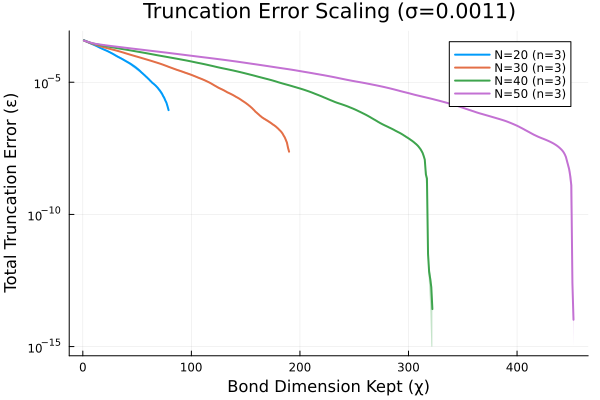

In [25]:
using Statistics

Ns = [20, 30, 40, 50]
σ_fan = 0.0011

p3 = plot(title="Truncation Error Scaling (σ=$σ_fan)", yaxis=:log10,
          xlabel="Bond Dimension Kept (χ)", ylabel="Total Truncation Error (ε)", legend=:topright, grid=true)

for (i, N) in enumerate(Ns)
    c_mpss, d_mpss = fetch_states(N, σ_fan, sysparams; max=3, type=:all)

    num_instances = min(length(c_mpss), length(d_mpss))
    if num_instances == 0
        continue
    end

    all_s_res = Vector{Float64}[]
    cutoffs = Int[]

    for j in 1:num_instances
        p_cln, p_dis = c_mpss[j], d_mpss[j]
        p_res = get_residual_state(p_dis, p_cln; normalize=false)

        s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
        push!(all_s_res, s_res)
        push!(cutoffs, maxlinkdim(p_cln))
    end

    max_chi = maximum(length.(all_s_res))

    valid_k = Int[]
    avg_epsilons = Float64[]
    lower_errors = Float64[]
    upper_errors = Float64[]

    for k in 1:(max_chi - 1)
        eps_k = [truncation_error(s_res, k) for s_res in all_s_res]
        avg_eps = mean(eps_k)

        if avg_eps < 1e-14
            break
        end

        err_eps = num_instances > 1 ? std(eps_k) / sqrt(num_instances) : 0.0

        push!(valid_k, k)
        push!(avg_epsilons, avg_eps)

        push!(lower_errors, min(err_eps, avg_eps - 1e-15))
        push!(upper_errors, err_eps)
    end

    plot!(p3, valid_k, avg_epsilons,
          ribbon=(lower_errors, upper_errors), fillalpha=0.3,
          label="N=$N (n=$num_instances)", lw=2)
end

display(p3)

In [ ]:
function calculate_renyi_entropy(spec::Vector{Float64}, α::Float64)::Float64
    # 1. Filter out exact zeros and numerical floating-point noise
    # (Since p_i < 0 is impossible, and log(0) crashes)
    p = filter(x -> x > 1e-16, spec)

    # 2. Handle the special von Neumann limit (α = 1.0)
    if abs(α - 1.0) < 1e-10
        return -sum(p_i * log(p_i) for p_i in p)
    end

    # 3. Handle the general Rényi entropy (α ≠ 1.0)
    return log(sum(p_i^α for p_i in p)) / (1.0 - α)
end

calculate_renyi_entropy (generic function with 1 method)

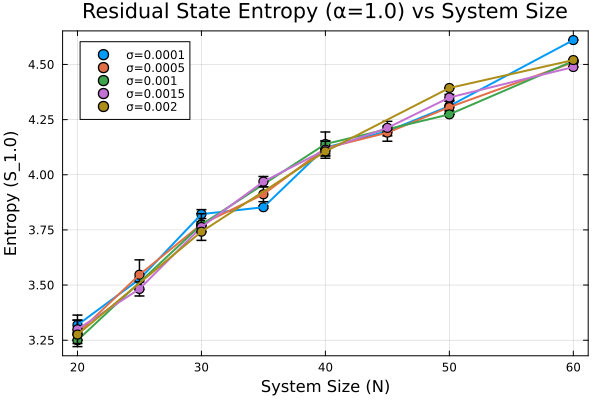

In [ ]:
Ns = [20, 25, 30, 35, 40, 45, 50, 60]
sigmas = [0.0001, 0.0005, 0.001, 0.0015, 0.002]
alpha_renyi = 1.0

p_ent = plot(title="Residual State Entropy (α=$alpha_renyi) vs System Size",
             xlabel="System Size (N)",
             ylabel="Entropy (S_$(alpha_renyi))",
             legend=:topleft,
             grid=true,
             framestyle=:box)

for (idx, σ) in enumerate(sigmas)
    avg_S = Float64[]
    err_S = Float64[]
    valid_Ns = Int[]

    for N in Ns
        c_mpss, d_mpss = fetch_states(N, σ, sysparams; max=3, type=:all)
        num_instances = min(length(c_mpss), length(d_mpss))
        if num_instances == 0
            continue
        end

        S_instances = Float64[]

        for j in 1:num_instances
            p_cln, p_dis = c_mpss[j], d_mpss[j]
            p_res = get_residual_state(p_dis, p_cln; normalize=true)
            s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
            S = calculate_renyi_entropy(s_res, alpha_renyi)
            push!(S_instances, S)
        end

        if !isempty(S_instances)
            push!(valid_Ns, N)
            push!(avg_S, mean(S_instances))
            if length(S_instances) > 1
                push!(err_S, std(S_instances) / sqrt(length(S_instances)))
            else
                push!(err_S, 0.0)
            end
        end
    end

    if !isempty(valid_Ns)
        scatter!(p_ent, valid_Ns, avg_S, yerror=err_S,
                 label="σ=$(σ)", color=idx, markersize=5, markerstrokewidth=1.5)
        plot!(p_ent, valid_Ns, avg_S, color=idx, lw=2, label=false)
    end
end

display(p_ent)

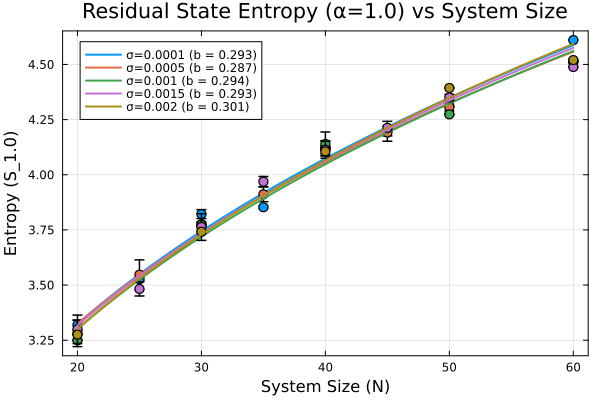

In [ ]:
using Statistics
using Plots

Ns = [20, 25, 30, 35, 40, 45, 50, 60]
sigmas = [0.0001, 0.0005, 0.001, 0.0015, 0.002]
alpha_renyi = 1.0

p_ent = plot(title="Residual State Entropy (α=$alpha_renyi) vs System Size",
             xlabel="System Size (N)",
             ylabel="Entropy (S_$(alpha_renyi))",
             legend=:topleft,
             grid=true,
             framestyle=:box)

for (idx, σ) in enumerate(sigmas)
    avg_S = Float64[]
    err_S = Float64[]
    valid_Ns = Int[]

    for N in Ns
        c_mpss, d_mpss = fetch_states(N, σ, sysparams; max=3, type=:all)
        num_instances = min(length(c_mpss), length(d_mpss))
        if num_instances == 0
            continue
        end

        S_instances = Float64[]

        for j in 1:num_instances
            p_cln, p_dis = c_mpss[j], d_mpss[j]

            p_res = get_residual_state(p_dis, p_cln; normalize=true)
            s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)

            S = calculate_renyi_entropy(s_res, alpha_renyi)
            push!(S_instances, S)
        end

        if !isempty(S_instances)
            push!(valid_Ns, N)
            push!(avg_S, mean(S_instances))

            if length(S_instances) > 1
                push!(err_S, std(S_instances) / sqrt(length(S_instances)))
            else
                push!(err_S, 0.0)
            end
        end
    end

    if length(valid_Ns) >= 2
        # Fit S = A * N^b  =>  ln(S) = ln(A) + b * ln(N)
        coeffs = hcat(log.(valid_Ns), ones(length(valid_Ns))) \ log.(avg_S)
        b_pow = coeffs[1]
        A_pow = exp(coeffs[2])

        scatter!(p_ent, valid_Ns, avg_S, yerror=err_S,
                 label=false, color=idx, markersize=5, markerstrokewidth=1.5)

        N_smooth = range(minimum(valid_Ns), maximum(valid_Ns), length=100)
        S_smooth = A_pow .* (N_smooth .^ b_pow)

        lbl = "σ=$(σ) (b = $(round(b_pow, digits=3)))"
        plot!(p_ent, N_smooth, S_smooth, color=idx, lw=2, label=lbl)

    elseif length(valid_Ns) == 1
        scatter!(p_ent, valid_Ns, avg_S, yerror=err_S,
                 label="σ=$(σ)", color=idx, markersize=5, markerstrokewidth=1.5)
    end
end

display(p_ent)

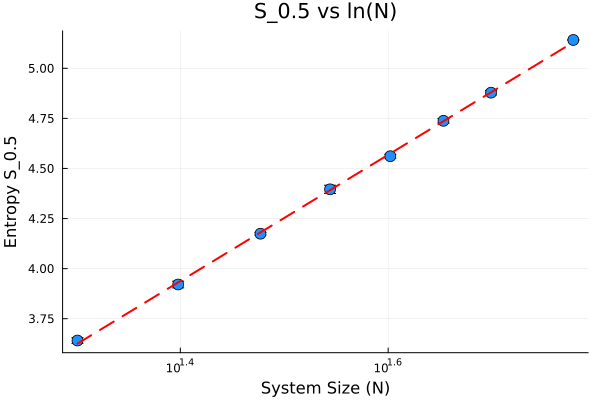

In [ ]:
using Statistics
using Plots

alpha_renyi = 0.5
Ns = [20, 25, 30, 35, 40, 45, 50, 60]
σ_test = 0.0019

avg_S = Float64[]
err_S = Float64[]
valid_Ns = Int[]

for N in Ns
    c_mpss, d_mpss = fetch_states(N, σ_test, sysparams; max=3, type=:all)
    num_instances = min(length(c_mpss), length(d_mpss))
    if num_instances == 0 continue end

    S_instances = Float64[]
    for j in 1:num_instances
        p_res = get_residual_state(d_mpss[j], c_mpss[j]; normalize=true)
        s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
        push!(S_instances, calculate_renyi_entropy(s_res, alpha_renyi))
    end

    push!(valid_Ns, N)
    push!(avg_S, mean(S_instances))
    push!(err_S, length(S_instances) > 1 ? std(S_instances)/sqrt(length(S_instances)) : 0.0)
end

p_semilog = scatter(valid_Ns, avg_S, yerror=err_S,
                    title="S_$(alpha_renyi) vs ln(N)",
                    xlabel="System Size (N)",
                    ylabel="Entropy S_$(alpha_renyi)",
                    xaxis=:log10,
                    legend=false, color=:dodgerblue, grid=true, markersize=6)

coeffs_log = hcat(log.(valid_Ns), ones(length(valid_Ns))) \ avg_S
A_log, B_log = coeffs_log[1], coeffs_log[2]
N_smooth = range(minimum(valid_Ns), maximum(valid_Ns), length=100)
plot!(p_semilog, N_smooth, A_log .* log.(N_smooth) .+ B_log, color=:red, lw=2, linestyle=:dash)

display(p_semilog)

Fit Results:
χ_c(N) = 0.115 * N^1.458
Effective 'c' from (c/3) exponent = 4.375


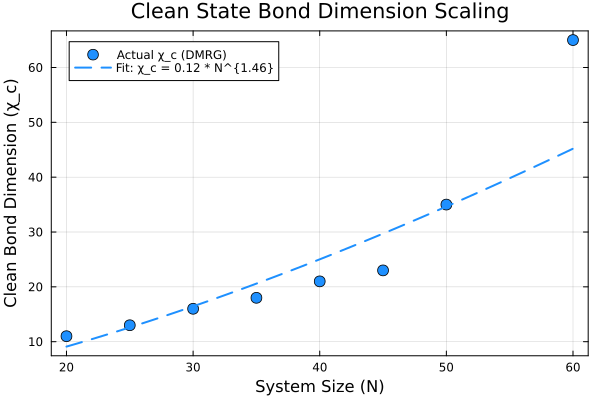

predicted_chi_c

In [ ]:
using Plots
using LinearAlgebra

# Define the system sizes you have simulated
Ns_clean = [20, 25, 30, 35, 40, 45, 50, 60]

chi_cs = Float64[]
valid_Ns_clean = Float64[]

# 1. Extract the clean bond dimension for each N
for N in Ns_clean
    # Fetch only the clean states (σ = 0.0)
    c_mpss, _ = fetch_states(N, 0.0001, sysparams; max=1, type=:latest)

    if isempty(c_mpss)
        continue
    end

    psi_cln = c_mpss[1]

    # maxlinkdim(psi) gives us the exact χ_c kept by DMRG for the clean state
    push!(chi_cs, maxlinkdim(psi_cln))
    push!(valid_Ns_clean, N)
end

# 2. Fit to the model: χ_c = A * N^(c/3)
# Taking the log: ln(χ_c) = ln(A) + (c/3) * ln(N)
X_matrix = hcat(log.(valid_Ns_clean), ones(length(valid_Ns_clean)))
y_vec = log.(chi_cs)

coeffs_cln = X_matrix \ y_vec
gamma = coeffs_cln[1]      # This is the exponent (c/3)
A_cln = exp(coeffs_cln[2]) # This is the prefactor A

c_effective = gamma * 3

println("Fit Results:")
println("χ_c(N) = $(round(A_cln, digits=3)) * N^$(round(gamma, digits=3))")
println("Effective 'c' from (c/3) exponent = $(round(c_effective, digits=3))")

# 3. Plot to verify the fit visually
p_cln = plot(title="Clean State Bond Dimension Scaling",
             xlabel="System Size (N)", ylabel="Clean Bond Dimension (χ_c)",
             yaxis=:log10, xaxis=:log10, legend=:topleft, grid=true, framestyle=:box)

scatter!(p_cln, valid_Ns_clean, chi_cs,
         label="Actual χ_c (DMRG)", color=:dodgerblue, markersize=6)

N_smooth_cln = range(minimum(valid_Ns_clean), maximum(valid_Ns_clean), length=100)
chi_fit_line = A_cln .* (N_smooth_cln .^ gamma)

plot!(p_cln, N_smooth_cln, chi_fit_line,
      label="Fit: χ_c = $(round(A_cln, digits=2)) * N^{$(round(gamma, digits=2))}",
      color=:dodgerblue, lw=2, linestyle=:dash)

display(p_cln)

# 4. The requested predictive function for downstream use
"""
    predicted_chi_c(N::Int)

Returns the mathematically predicted clean bond dimension for a given system size
based on the fitted N^(c/3) scaling law.
"""
function predicted_chi_c(N::Int)::Float64
    return A_cln * (N ^ gamma)
end

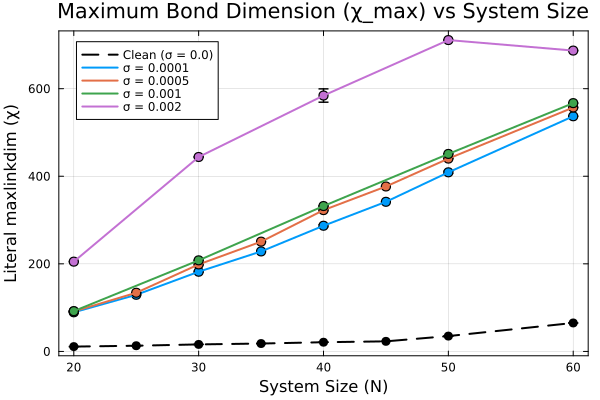

In [ ]:
using Statistics
using Plots

# --- PLOT: Literal maxlinkdim vs System Size (Clean + Disordered) ---
Ns = [20, 25, 30, 35, 40, 45, 50, 60]
sigmas = [0.0001, 0.0005, 0.001, 0.002] # Only actual disordered sigmas here!

# Initialize the plot
p_chi_literal = plot(title="Maximum Bond Dimension (χ_max) vs System Size",
             xlabel="System Size (N)",
             ylabel="Literal maxlinkdim (χ)",
             legend=:topleft, grid=true, framestyle=:box)

# ==========================================
# 1. PLOT THE CLEAN BASELINE (From c_mpss)
# ==========================================
valid_Ns_clean = Int[]
avg_chis_clean = Float64[]
err_chis_clean = Float64[]

for N in Ns
    # We can use the very first sigma to locate the files and grab the clean states
    c_mpss, _ = fetch_states(N, sigmas[1], sysparams; max=3, type=:all)

    num_instances = length(c_mpss)
    if num_instances == 0
        continue
    end

    instance_chis = Float64[]
    for j in 1:num_instances
        # Get the literal bond dimension of the CLEAN state
        push!(instance_chis, maxlinkdim(c_mpss[j]))
    end

    push!(valid_Ns_clean, N)
    push!(avg_chis_clean, mean(instance_chis))

    if length(instance_chis) > 1
        push!(err_chis_clean, std(instance_chis) / sqrt(length(instance_chis)))
    else
        push!(err_chis_clean, 0.0)
    end
end

if !isempty(valid_Ns_clean)
    # Scatter points with error bars (hidden from legend)
    scatter!(p_chi_literal, valid_Ns_clean, avg_chis_clean, yerror=err_chis_clean,
             color=:black, label=false, markersize=5, markerstrokewidth=1.5)
    # The clean connecting line
    plot!(p_chi_literal, valid_Ns_clean, avg_chis_clean,
          color=:black, lw=2, linestyle=:dash, label="Clean (σ = 0.0)")
end

# ==========================================
# 2. PLOT THE DISORDERED STATES (From d_mpss)
# ==========================================
for (idx, σ) in enumerate(sigmas)
    valid_Ns = Int[]
    avg_chis = Float64[]
    err_chis = Float64[]

    for N in Ns
        # Now we grab the disordered states for this specific sigma
        _, d_mpss = fetch_states(N, σ, sysparams; max=3, type=:all)

        num_instances = length(d_mpss)
        if num_instances == 0
            continue
        end

        instance_chis = Float64[]
        for j in 1:num_instances
            # Get the literal bond dimension of the DISORDERED state
            push!(instance_chis, maxlinkdim(d_mpss[j]))
        end

        push!(valid_Ns, N)
        push!(avg_chis, mean(instance_chis))

        if length(instance_chis) > 1
            push!(err_chis, std(instance_chis) / sqrt(length(instance_chis)))
        else
            push!(err_chis, 0.0)
        end
    end

    if !isempty(valid_Ns)
        # Scatter points with error bars
        scatter!(p_chi_literal, valid_Ns, avg_chis, yerror=err_chis,
                 color=idx, label=false, markersize=5, markerstrokewidth=1.5)
        # The disordered connecting line
        plot!(p_chi_literal, valid_Ns, avg_chis,
              color=idx, lw=2, linestyle=:solid, label="σ = $(round(σ, digits=4))")
    end
end

display(p_chi_literal)

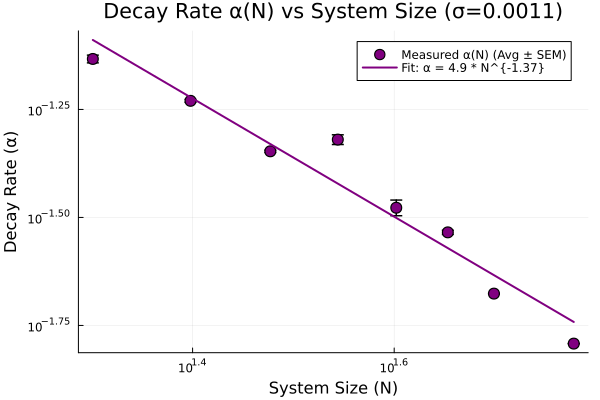

In [ ]:
using Statistics

Ns = [20, 25, 30, 35, 40, 45, 50, 60]
σ_fan = 0.0011

valid_Ns = Int[]
avg_alphas = Float64[]
err_alphas = Float64[]

for N in Ns
    c_mpss, d_mpss = fetch_states(N, σ_fan, sysparams; max=3, type=:all)

    num_instances = min(length(c_mpss), length(d_mpss))
    if num_instances == 0
        continue
    end

    instance_alphas = Float64[]

    for j in 1:num_instances
        p_cln, p_dis = c_mpss[j], d_mpss[j]
        p_res = get_residual_state(p_cln, p_dis; normalize=false)

        s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
        χ_c = maxlinkdim(p_cln)

        epsilons = [truncation_error(s_res, k) for k in 1:length(s_res)-1]

        valid_indices = findall(x -> x > 0.0, epsilons)

        if !isempty(valid_indices)
            idx_start = max(χ_c + 2, valid_indices[1])
            idx_end = valid_indices[end]

            if idx_start < idx_end
                eps_fit = epsilons[idx_start:idx_end]
                chi_fit = (idx_start:idx_end)

                coeffs = hcat(Float64.(chi_fit), ones(length(chi_fit))) \ log.(eps_fit)
                push!(instance_alphas, -coeffs[1])
            end
        end
    end

    if !isempty(instance_alphas)
        push!(valid_Ns, N)
        push!(avg_alphas, mean(instance_alphas))

        if length(instance_alphas) > 1
            push!(err_alphas, std(instance_alphas) / sqrt(length(instance_alphas)))
        else
            push!(err_alphas, 0.0)
        end
    end
end

coeffs_power = hcat(log.(valid_Ns), ones(length(valid_Ns))) \ log.(avg_alphas)
b_power = -coeffs_power[1]
A_power = exp(coeffs_power[2])

p4 = plot(title="Decay Rate α(N) vs System Size (σ=$σ_fan)",
          xlabel="System Size (N)", ylabel="Decay Rate (α)",
          yaxis=:log10, xaxis=:log10, grid=true)

scatter!(p4, valid_Ns, avg_alphas, yerror=err_alphas,
         label="Measured α(N) (Avg ± SEM)", color=:purple, markersize=6, markerstrokewidth=1.5)

N_smooth = range(minimum(valid_Ns), maximum(valid_Ns), length=100)
plot!(p4, N_smooth, A_power .* (N_smooth .^ -b_power),
      label="Fit: α = $(round(A_power, digits=2)) * N^{-$(round(b_power, digits=2))}",
      color=:purple, lw=2)

display(p4)

In [ ]:
using Statistics
using Plots

Ns = [20, 25, 30, 35, 40, 45, 50, 60]
sigmas = 0.0001:0.0001:0.002

p4 = plot(title="Decay Rate α(N) vs System Size",
          xlabel="System Size (N)", ylabel="Decay Rate (α)",
          yaxis=:log10, xaxis=:log10, grid=true, legend=:bottomleft)

valid_sigmas_b = Float64[]
extracted_bs = Float64[]

for (idx, σ) in enumerate(sigmas)
    valid_Ns = Int[]
    avg_alphas = Float64[]
    err_alphas = Float64[]

    for N in Ns
        c_mpss, d_mpss = fetch_states(N, σ, sysparams; max=3, type=:all)

        num_instances = min(length(c_mpss), length(d_mpss))
        if num_instances == 0
            continue
        end

        instance_alphas = Float64[]

        for j in 1:num_instances
            p_cln, p_dis = c_mpss[j], d_mpss[j]

            p_res = get_residual_state(p_dis, p_cln; normalize=false)

            s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
            χ_c = maxlinkdim(p_cln)

            epsilons = [truncation_error(s_res, k) for k in 1:length(s_res)-1]

            valid_indices = findall(x -> x > 0.0, epsilons)

            if !isempty(valid_indices)
                idx_start = max(χ_c + 2, valid_indices[1])
                idx_end = valid_indices[end]

                if idx_start < idx_end
                    eps_fit = epsilons[idx_start:idx_end]
                    chi_fit = (idx_start:idx_end)

                    coeffs = hcat(Float64.(chi_fit), ones(length(chi_fit))) \ log.(eps_fit)
                    push!(instance_alphas, -coeffs[1])
                end
            end
        end

        if !isempty(instance_alphas)
            push!(valid_Ns, N)
            push!(avg_alphas, mean(instance_alphas))

            if length(instance_alphas) > 1
                push!(err_alphas, std(instance_alphas) / sqrt(length(instance_alphas)))
            else
                push!(err_alphas, 0.0) # No error bar if only 1 instance exists
            end
        end
    end

    if length(valid_Ns) >= 2
        coeffs_power = hcat(log.(valid_Ns), ones(length(valid_Ns))) \ log.(avg_alphas)
        b_power = -coeffs_power[1]
        A_power = exp(coeffs_power[2])

        push!(valid_sigmas_b, σ)
        push!(extracted_bs, b_power)

        scatter!(p4, valid_Ns, avg_alphas, yerror=err_alphas,
                 label=false, color=idx, markersize=5, markerstrokewidth=1.5)

        N_smooth = range(minimum(valid_Ns), maximum(valid_Ns), length=100)
        lbl = "σ=$(round(σ, digits=4)) (b=$(round(b_power, digits=3)))"
        plot!(p4, N_smooth, A_power .* (N_smooth .^ -b_power),
              label=lbl, color=idx, lw=2)
    else
        println("Warning: Not enough valid data points to fit σ = $σ")
    end
end

display(p4)

if !isempty(valid_sigmas_b)
    p_b = scatter(valid_sigmas_b, extracted_bs,
                  title="Scaling Exponent (b) vs Disorder (σ)",
                  xlabel="Disorder Strength (σ)",
                  ylabel="Polynomial Exponent (b)",
                  legend=:bottomright, grid=true, color=:darkred, markersize=6)

    mean_b = mean(extracted_bs)
    hline!(p_b, [mean_b], linestyle=:dash, color=:black, label="Mean b = $(round(mean_b, digits=3))")

    display(p_b)
end

error in running finalizer: InterruptException()
try_close_finalizer at /Users/jamesneville-rolfe/.julia/packages/HDF5/Z859u/src/api/lock.jl:6
unknown function (ip: 0x1509600ff)
_jl_invoke at /Users/julia/.julia/scratchspaces/a66863c6-20e8-4ff4-8a62-49f30b1f605e/agent-cache/default-honeycrisp-XC9YQX9HH2.0/build/default-honeycrisp-XC9YQX9HH2-0/julialang/julia-release-1-dot-10/src/gf.c:0 [inlined]
ijl_apply_generic at /Users/julia/.julia/scratchspaces/a66863c6-20e8-4ff4-8a62-49f30b1f605e/agent-cache/default-honeycrisp-XC9YQX9HH2.0/build/default-honeycrisp-XC9YQX9HH2-0/julialang/julia-release-1-dot-10/src/gf.c:3077
run_finalizer at /Users/julia/.julia/scratchspaces/a66863c6-20e8-4ff4-8a62-49f30b1f605e/agent-cache/default-honeycrisp-XC9YQX9HH2.0/build/default-honeycrisp-XC9YQX9HH2-0/julialang/julia-release-1-dot-10/src/gc.c:318
jl_gc_run_finalizers_in_list at /Users/julia/.julia/scratchspaces/a66863c6-20e8-4ff4-8a62-49f30b1f605e/agent-cache/default-honeycrisp-XC9YQX9HH2.0/build/default-hon

InterruptException: InterruptException: